# Compute the number of generations since admixture from admixture tract lengths

In [1]:
import numpy as np
import patsy as ps
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina', 'png')
import seaborn as sns
sns.set()
sns.set_style('ticks')

### Generate some dummy exponentially distributed length data

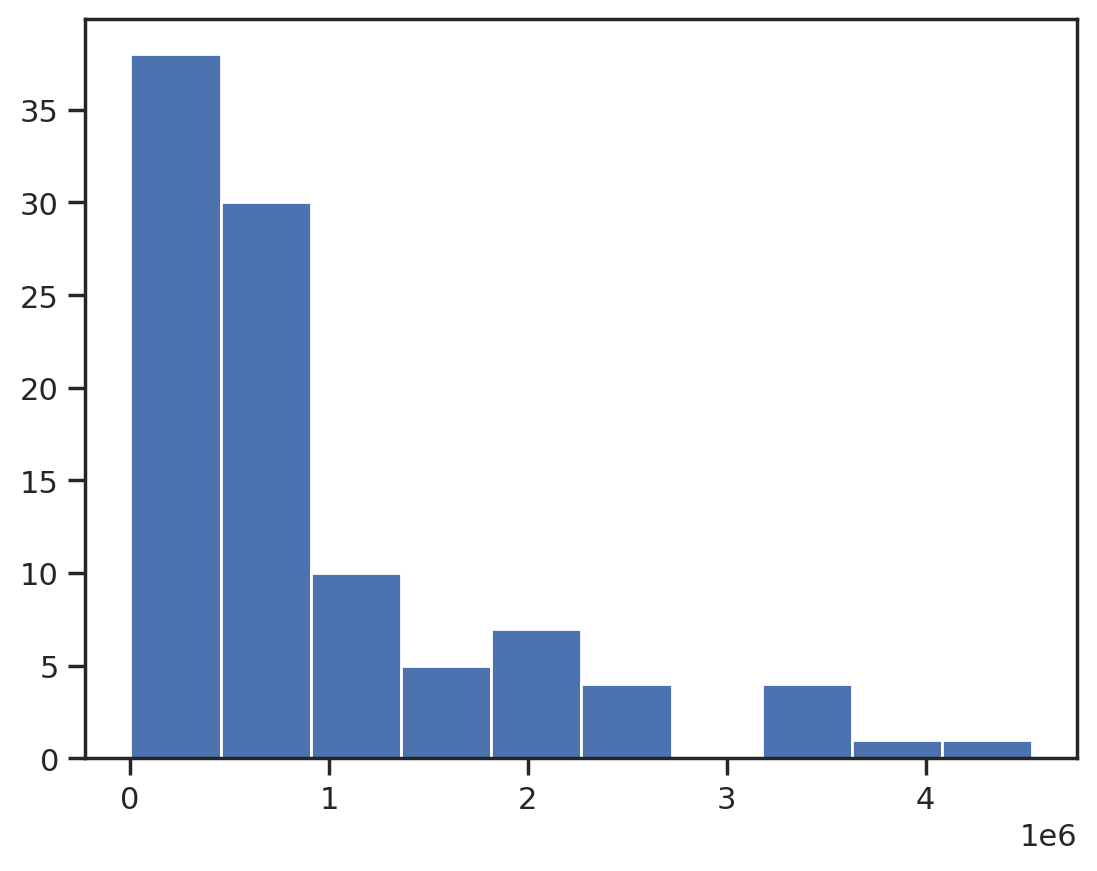

In [2]:
# dummy length data
from numpy.random import exponential
phys_lengths = exponential(scale=1000000, size=100) #+ 1000000000
plt.hist(phys_lengths) ;

In [3]:
mean_rec_rate = 1e-8
lengths = phys_lengths * mean_rec_rate

### Compute the empirical CDF

In [4]:
def ecdf(data):
    """ Compute ECDF """
    x = np.sort(data)
    n = x.size
    y = np.arange(1, n+1) / n
    return x, y

val, prob = ecdf(lengths)

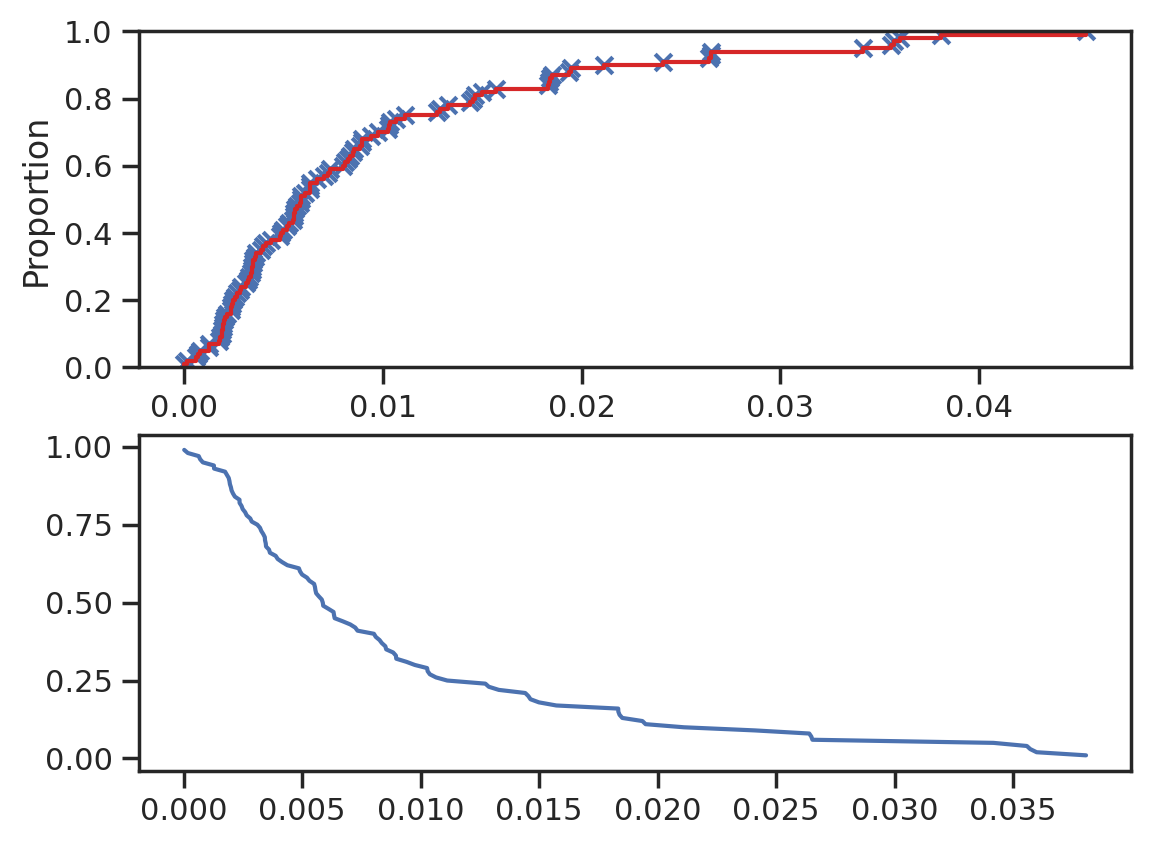

In [5]:
plt.subplot(211)
plt.scatter(val, prob, marker='x')
# sanity check
sns.ecdfplot(x=val, color='tab:red') 

# PDF
plt.subplot(212)
d, p = val[:-1], 1-prob[:-1] # leave out last one to avoid division by zero
plt.plot(d, p) ;

### Estimate the number of generations

The admixture is likely not the result of a single admixture event, but if we assume that it is, the length distribution of tracts is well approximated by $y=Ae^{−(n−1)d}$. Here $n$ is the number of generations since the admixture event and $d$ is genetic distance (physical length times mean recombination rate per base) and $A$ is a scaling factor. We fit a line to the log of the complementary cummulative distribution (the PDF) of tract lengths and, since $\ln(y)=−(n−1)d+\ln(A)$, the slope of the fitted line is n−1.

Intercept     -0.035968
d           -104.081494
dtype: float64

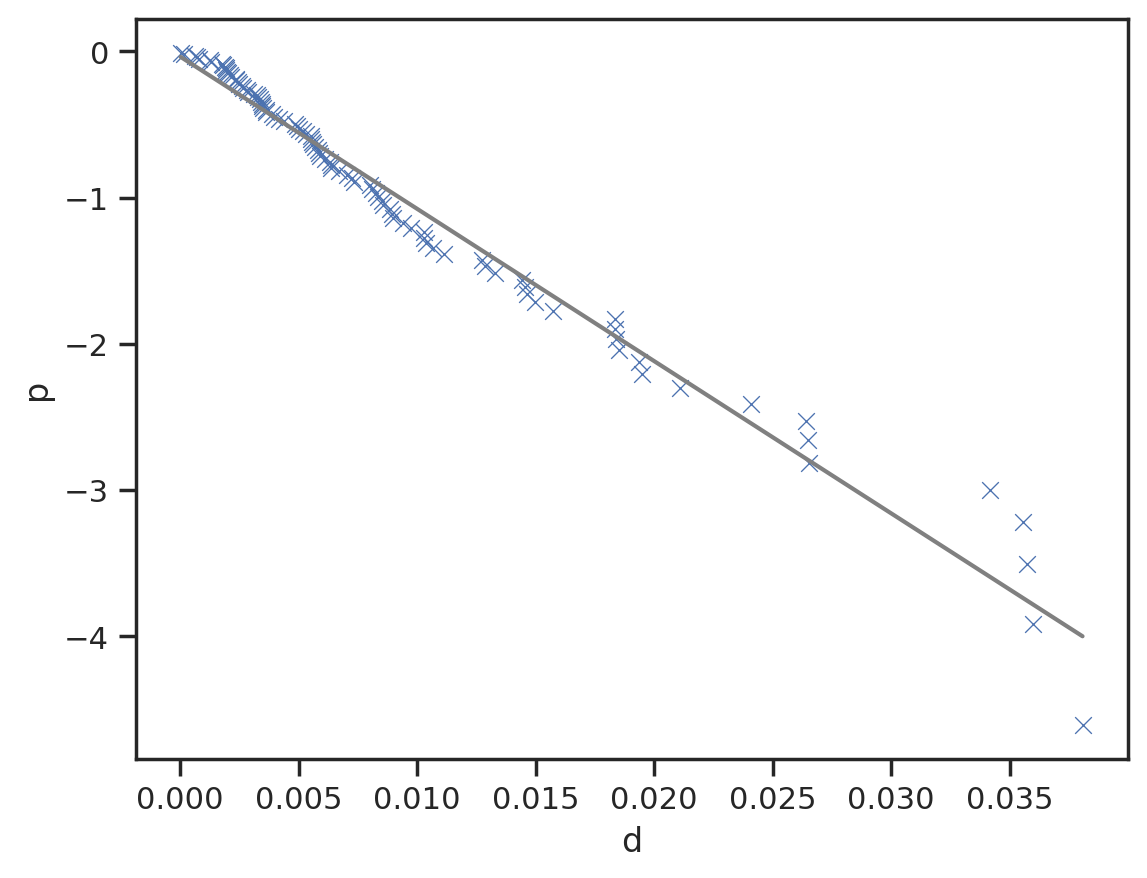

In [6]:
# mask = ~np.isnan(x)
# df = pd.DataFrame(dict(d=d[mask], p=np.log(1-p[mask])))

df = pd.DataFrame(dict(d=d, p=np.log(p)))

y, X = ps.dmatrices('p ~ d',data = df, return_type = 'dataframe')
model = sm.OLS(y,X)
results = model.fit()
predicted_p = results.predict()
p_residuals = df.p - predicted_p

ax = sns.scatterplot(x=df.d, y=df.p, marker='x');
ax.plot(df.d, predicted_p, color='grey', marker=None);
results.params

Generations since admixture pulse is:

In [7]:
round(-results.params.d + 1)

105

Loading in data for Tanzania and Ethiopia

In [8]:
def create_paint_df_ind_compressed(df, ind, mapping, ns_map):
    d = {}
    max_pos = int(df.epos.iloc[-1])
    df = df.loc[df[ind].shift() != df[ind]].reset_index()
    df["epos"] = pd.concat([df.spos.iloc[1:], pd.Series(max_pos)], ignore_index=True)
    d["pos"] = df.spos
    d["end_pos"] = df.epos -1
    d["length"] = df.epos - df.spos
    d["reference"] = df[ind].map(mapping)
    d["n/s"] = d["reference"].map(ns_map)
    d["individual"] = ind[:-2]
    d["haplotype"] = ind[-1:]
    return pd.DataFrame(d)

meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/tanzania_pure_focus/"
mapping_df = pd.read_csv("../steps/rfmix_gen100/tanzania_close_focus/" + "ref_names.txt", sep = "\t", names=["ID", "Origin"])

pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o
north_south_mapping = {'Gog Woreda, Gambella region, Ethiopia': 1,
                         'Mikumi, Tanzania': 0,
                          'Mahale, Tanzania': 0}
df_l = []
for chrom in ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)
df_l = []
for c in ["chr{}".format(x) for x in (range(1, 21))] + ["chrX"]:
    genetic_map = "/home/eriks/baboondiversity/data/PG_panu3_recombination_map/mikumi_pyrho_genetic_map_{}.txt"
    chr_recomb = pd.read_csv(genetic_map.format(c), sep=" ")
    df_l.append(chr_recomb)
recomb_df = pd.concat(df_l)

chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
all_chrX
female_chrX


In [9]:
df_l = []
for c in length_df.chrom.unique():
    print(c)
    
    l_df = length_df.loc[length_df.chrom == c].copy()
    if c == "female_chrX" or c == "all_chrX":
        c = "chrX"
    r_df = recomb_df.loc[(recomb_df.chromosome == c)]
    pos_mapping = dict(zip(r_df.position, r_df["Genetic_Map(cM)"]))
    l_df["start_cM"] = l_df.pos.map(pos_mapping)
    l_df["end"] = l_df.end_pos + 1
    l_df["end_cM"] = l_df.end.map(pos_mapping)
    df_l.append(l_df)
df = pd.concat(df_l)

chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
all_chrX
female_chrX


In [10]:
meta_data_samples_sci = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")

df["Species"] = df.individual.map(dict(zip(meta_data_samples_sci.PGDP_ID, meta_data_samples_sci.Species)))
df["Origin"] = df.individual.map(dict(zip(meta_data_samples_sci.PGDP_ID, meta_data_samples_sci.Origin)))

length_df_tanz = pd.concat([df])

In [11]:
length_df_tanz

,pos,end_pos,length,reference,n/s,individual,haplotype,chrom,start_cM,end,end_cM,Species,Origin
0,160,2597651,2597492,"Gog Woreda, Gambella region, Ethiopia",1,Sci_30877,0,chr1,0.000057,2597652,4.575039,anubis,"Aberdare, Kenya"
1,2597652,2701074,103423,"Mahale, Tanzania",0,Sci_30877,0,chr1,4.575039,2701075,4.786100,anubis,"Aberdare, Kenya"
2,2701075,7127661,4426587,"Gog Woreda, Gambella region, Ethiopia",1,Sci_30877,0,chr1,4.786100,7127662,10.566631,anubis,"Aberdare, Kenya"
3,7127662,7682838,555177,"Mikumi, Tanzania",0,Sci_30877,0,chr1,10.566631,7682839,10.907593,anubis,"Aberdare, Kenya"
4,7682839,30793683,23110845,"Gog Woreda, Gambella region, Ethiopia",1,Sci_30877,0,chr1,10.907593,30793684,41.523063,anubis,"Aberdare, Kenya"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,70356540,70444229,87690,"Mikumi, Tanzania",0,PD_0792,0,female_chrX,62.923065,70444230,63.043297,kindae,"Chunga, Zambia"
6,70444230,143691565,73247336,"Mahale, Tanzania",0,PD_0792,0,female_chrX,63.043297,143691566,127.257801,kindae,"Chunga, Zambia"
0,37,51697767,51697731,"Mahale, Tanzania",0,PD_0792,1,female_chrX,0.000000,51697768,48.287723,kindae,"Chunga, Zambia"
1,51697768,52628994,931227,"Mikumi, Tanzania",0,PD_0792,1,female_chrX,48.287723,52628995,48.666787,kindae,"Chunga, Zambia"


In [13]:
#Selecting the cases of interest and setting Minor Parent Ancestry
origins_interest = ['Arusha, Tanzania',
       'Gog Woreda, Gambella region, Ethiopia',
       'Gombe, Tanzania', 'Issa Valley, Tanzania',
       'Katavi, Tanzania','Lake Manyara, Tanzania',
       'Mahale, Tanzania',
       'Mikumi, Tanzania', 'Ngorongoro, Tanzania', 'Ruaha, Tanzania',
       'Selous, Tanzania', 'Serengeti, Tanzania', 'Tarangire, Tanzania',
       'Udzungwa, Tanzania']
length_df_tanz = length_df_tanz.loc[length_df_tanz.Origin.isin(origins_interest)]
length_df_tanz["minor_parent_percentage"] = [x if y == ("cynocephalus") 
                                             else 1-x for x, y, z in zip(length_df_tanz["n/s"],
                                                                         length_df_tanz["Species"],
                                                                        length_df_tanz["Origin"])]
length_df_tanz["cM_length"] = length_df_tanz.end_cM-length_df_tanz.start_cM

In [16]:
length_df_tanz["chrom_type"] = ["autosome" if x not in ['all_chrX', 'female_chrX'] else "chrX" for x in length_df_tanz.chrom]

In [17]:
length_sum = length_df_tanz.loc[length_df_tanz.minor_parent_percentage == 1].groupby(["individual", "chrom_type"])["length"].sum().reset_index()
length_median = length_df_tanz.loc[length_df_tanz.minor_parent_percentage == 1].groupby(["individual", "chrom_type"])["length"].median().reset_index()
length_df = length_df_tanz.groupby(["individual", "chrom_type"])["length"].sum().reset_index()
length_df = length_df.merge(length_sum, on=["individual","chrom_type"])
length_df = length_df.merge(length_median, on=["individual","chrom_type"])

In [18]:
length_df["Admix Proportion"] = length_df.length_y/length_df.length_x
length_df["Median Fragment"] = length_df.length

In [20]:
def ecdf(data):
    """ Compute ECDF """
    x = np.sort(data)
    n = x.size
    y = np.arange(1, n+1) / n
    return x, y

origin_l, date_l, morgan_l, mean_l, median_l, sum_l = [], [], [], [], [], []

for o in length_df_tanz.Origin.unique():
    print(o)
    s_df = length_df_tanz.loc[length_df_tanz.Origin == o]
    for ID in s_df.individual.unique():
        print(ID)
        ss_df = s_df.loc[(s_df.individual == ID) & (s_df["minor_parent_percentage"] == 1) &
                         ~(s_df.chrom).isin(["all_chrX", "female_chrX"])]
        lengths = ss_df.cM_length/100
        val, prob = ecdf(lengths.sort_values(ascending=False).iloc[:len(lengths)//5])
        d, p = val[:-1], 1-prob[:-1]
        m_df = pd.DataFrame(dict(d=d, p=np.log(p)))

        y, X = ps.dmatrices('p ~ d',data = m_df, return_type = 'dataframe')
        model = sm.GLM(y,X, var_weights=X.d)
        results = model.fit()
        predicted_p = results.predict()
        p_residuals = m_df.p - predicted_p
        print(round(-results.params.d + 1), lengths.mean(), lengths.median(), lengths.sum())
        origin_l.append(o), date_l.append(-results.params.d + 1), morgan_l.append(lengths.sum())
        mean_l.append(lengths.mean()*100), median_l.append(lengths.median()*100), sum_l.append(lengths.sum()*100)

Serengeti, Tanzania
PD_0199
156 0.0028922230463391103 0.0019324968831589651 2.3051017679322707
PD_0200
184 0.0030039011455705853 0.0020692904445147064 2.41213261989318
PD_0201
104 0.0032539675173942637 0.0022344127019886706 2.456745475632669
PD_0202
88 0.003005839221981817 0.002041637434330994 2.203280149712672
PD_0203
66 0.0030187233964712474 0.002053653546630585 2.4240348873664117
PD_0493
145 0.0028884978103592774 0.0019984290943734617 2.2876902658045477
PD_0494
132 0.003056652178091429 0.002026682676560654 2.399471959801772
PD_0495
235 0.0029473728605597938 0.0020545547218982566 2.2517928654676824
PD_0496
173 0.002808889270696936 0.0019819339024613213 2.0701513925036417
PD_0497
101 0.002904090577493295 0.002036073387382844 2.4162033604744217
PD_0498
128 0.00294328799385293 0.002030780633398681 2.478248490824167
PD_0499
100 0.003042072154958562 0.0020390042208102343 2.5310040329255235
PD_0500
91 0.0030562500880184197 0.0020486995395452823 2.686443827368191
PD_0501
200 0.0030181973427

/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/statsmodels/genmod/generalized_linear_model.py:813: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(resid / self.family.variance(mu)) / self.df_resid
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/statsmodels/regression/_tools.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  scale = np.dot(wresid, wresid) / df_resid
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/statsmodels/genmod/generalized_linear_model.py:1257: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


2579 0.0025586454655947555 0.0013499962531337494 0.0460556183807056
PD_0236
874 0.0021163616129762676 0.0017012467070205161 0.08677082613202697
PD_0237
159 0.004087954698046792 0.0019411674299898607 0.16351818792187167
Lake Manyara, Tanzania
PD_0238
146 0.003321556748428735 0.00221416203029527 3.394630996894167
PD_0239
168 0.0033317184189784457 0.002316305834691761 3.30173295320764
PD_0240
180 0.0031725878029242056 0.0021636918419539785 3.1598974517125087
PD_0241
126 0.0031011370323647106 0.002114240484041403 3.1104404434618047
PD_0242
175 0.003221751984638846 0.002276648222967168 3.743675806150339
PD_0492
163 0.0034082649975977802 0.002321566502943284 3.3775906126194
PD_0674
221 0.003242595636982166 0.0023424391813755465 3.1777437242425224
PD_0675
135 0.003143698195093977 0.002280057834235691 3.1939973662154806
PD_0676
172 0.0033059608811098792 0.002271434623308934 3.3257966463965385
PD_0677
163 0.0033387837780337933 0.002300004107530871 3.312073507809523
PD_0678
169 0.003281774464164

In [21]:
date_df = pd.DataFrame({"Origin": origin_l, "Inferred date bases on fragment ecdf": date_l,
                        "Total admixture in Morgans": morgan_l,
                        "Total admixture in cM": sum_l,
                       "Mean admixture fragment length in cM": mean_l,
                       "Median admixture fragment length in cM": median_l})
#date_df["log_date"] = np.log(date_df["Inferred mean data base on fragment ecdf"])

[Text(0.5, 1.0, 'Admixture on the autosomes for Tanzanian populations')]

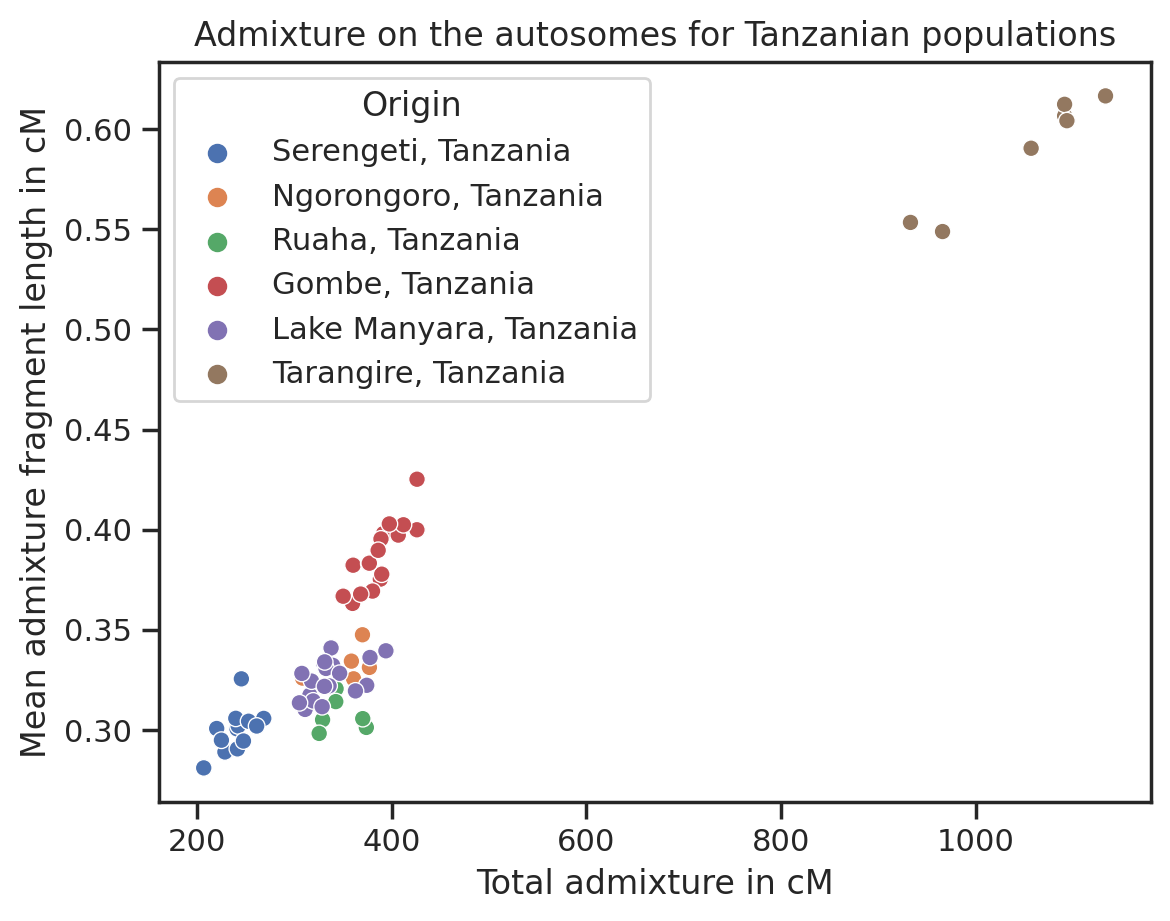

In [22]:
g = sns.scatterplot(data=date_df.loc[date_df.Origin.isin(["Serengeti, Tanzania",
                                                 "Tarangire, Tanzania",
                                                "Lake Manyara, Tanzania",
                                                "Ngorongoro, Tanzania",
                                                "Gombe, Tanzania",
                                                "Ruaha, Tanzania",
                                                "Mikumi, Tanzania"])], 
           x="Total admixture in cM", y="Mean admixture fragment length in cM", hue="Origin")
g.set(title="Admixture on the autosomes for Tanzanian populations")

<Axes: xlabel='Total admixture in cM', ylabel='Inferred date bases on fragment ecdf'>

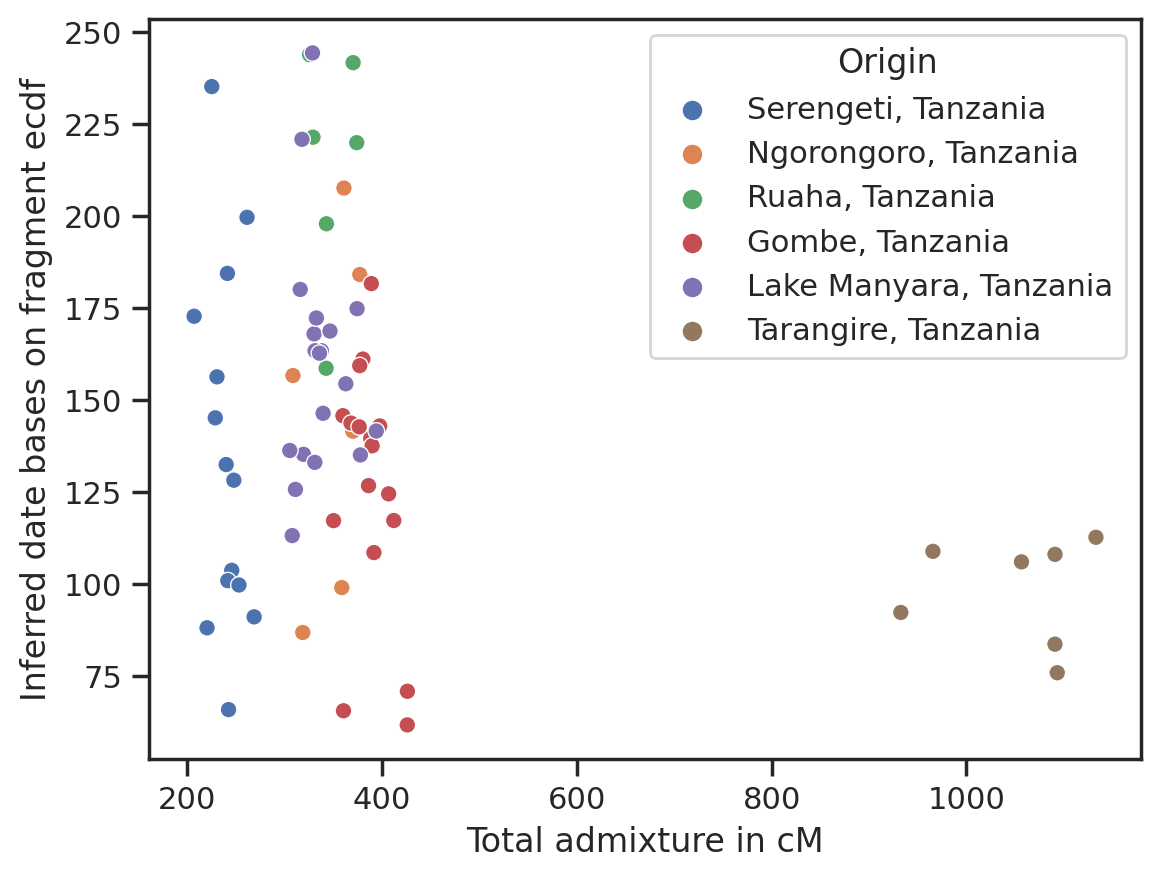

In [23]:
sns.scatterplot(data=date_df.loc[date_df.Origin.isin(["Serengeti, Tanzania",
                                                 "Tarangire, Tanzania",
                                                "Lake Manyara, Tanzania",
                                                "Ngorongoro, Tanzania",
                                                "Gombe, Tanzania",
                                                "Ruaha, Tanzania",
                                                "Mikumi, Tanzania"])], 
           x="Total admixture in cM", y="Inferred date bases on fragment ecdf", hue="Origin")

Intercept     0.371730
d           -71.682164
dtype: float64

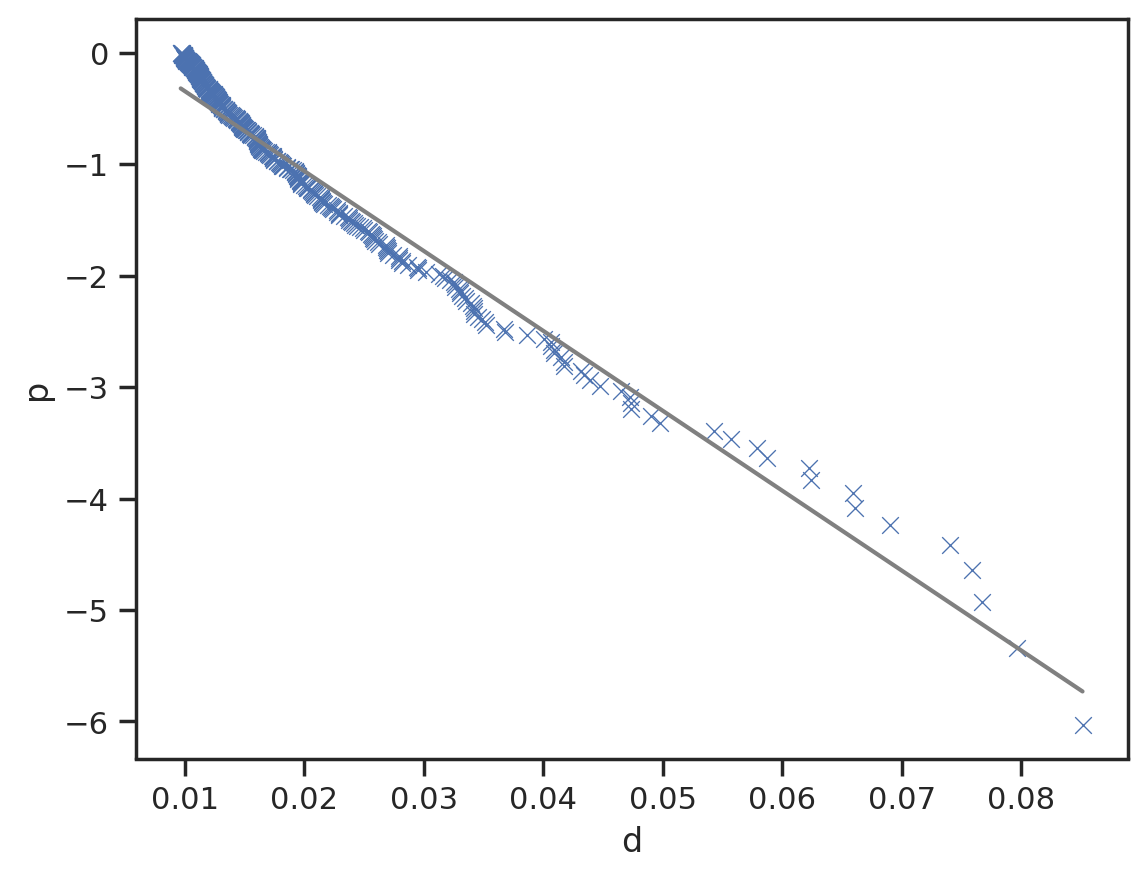

In [24]:
ax = sns.scatterplot(x=m_df.d, y=m_df.p, marker='x');
ax.plot(m_df.d, predicted_p, color='grey', marker=None);
results.params

<Axes: xlabel='cM_length', ylabel='Count'>

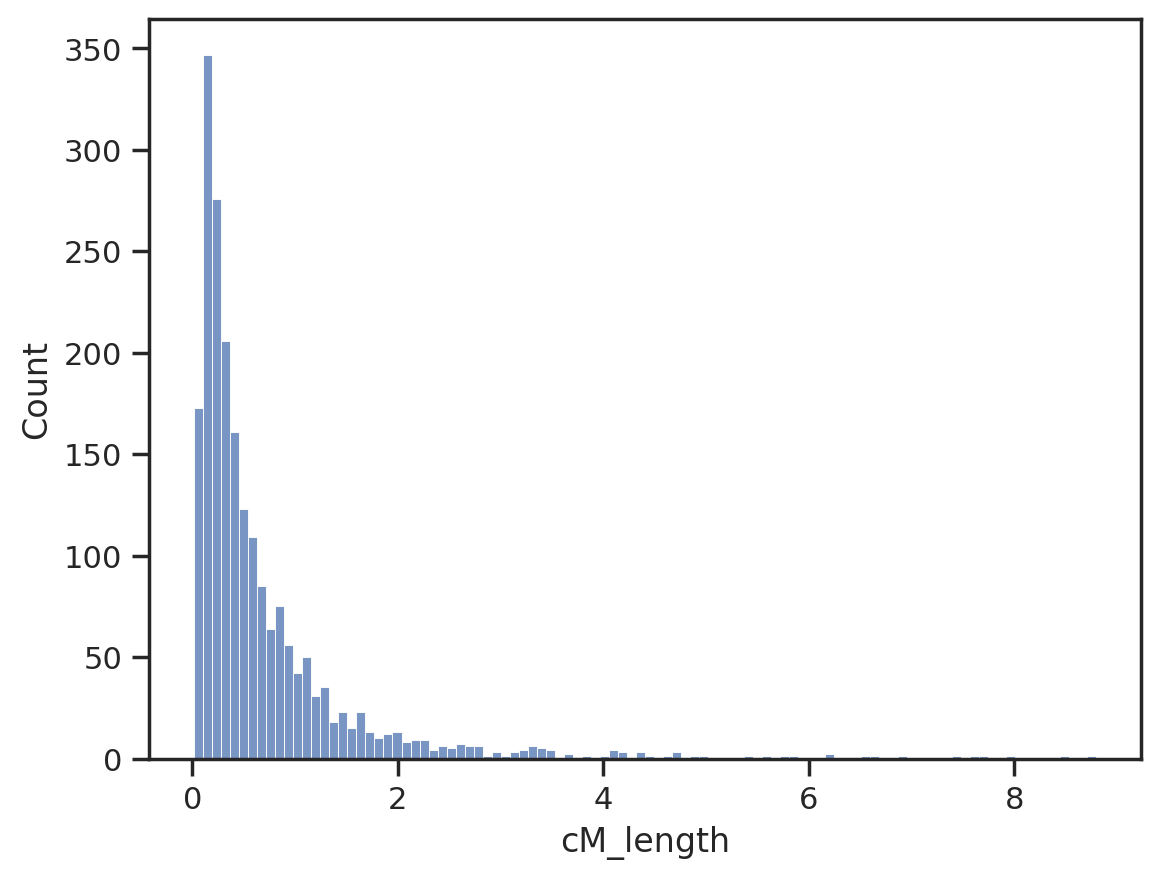

In [25]:
sns.histplot(ss_df.cM_length, bins=100)